In [ ]:
!pip install rdkit torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 48.3 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from rdkit import Chem



In [ ]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("yairschiff/zinc250k")

df = pd.DataFrame(ds["train"].to_pandas())

df = df.sample(5000, random_state=42)

smiles_list = df["smiles"].tolist()

print(len(smiles_list))
print(smiles_list[:5])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/19.9M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/2.20M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/224568 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/24887 [00:00<?, ? examples/s]

5000
['COc1ccc([C@@H]([NH3+])c2cscc2C)cc1C', 'CC(C)Cn1ccnc(NC[C@](C)(O)c2cccs2)c1=O', 'Cc1ccc(F)cc1C(=O)Nc1cccc(OC[C@@H]2CCCO2)c1', 'C[C@@H]1CCC[C@]2(CC(=O)NC(=O)[C@@H]2C)C1', 'COc1cccc(COc2ccc(C)nc2C[NH3+])n1']


smiles to adjacency matrix

In [ ]:
from rdkit import Chem
import numpy as np

SUPPORTED_ATOMS = ["C", "N", "O", "F", "P", "S", "Cl", "Br", "I"]
ATOM_TO_IDX = {a: i for i, a in enumerate(SUPPORTED_ATOMS)}

MAX_NODES = 40

In [ ]:
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    num_atoms = mol.GetNumAtoms()

    if num_atoms > MAX_NODES:
        return None

    # Node features (one-hot)
    node_features = np.zeros((MAX_NODES, len(SUPPORTED_ATOMS)))

    for i, atom in enumerate(mol.GetAtoms()):
        symbol = atom.GetSymbol()
        if symbol not in ATOM_TO_IDX:
            return None
        node_features[i, ATOM_TO_IDX[symbol]] = 1

    def get_bond_type(bond):
      if bond.GetBondType() == Chem.rdchem.BondType.SINGLE:
          return 1
      elif bond.GetBondType() == Chem.rdchem.BondType.DOUBLE:
          return 2
      elif bond.GetBondType() == Chem.rdchem.BondType.TRIPLE:
          return 3
      elif bond.GetBondType() == Chem.rdchem.BondType.AROMATIC:
          return 4
      else:
          return 0

    # Adjacency matrix
    adj = np.zeros((MAX_NODES, MAX_NODES))

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_type = get_bond_type(bond)
        adj[i, j] = bond_type
        adj[j, i] = bond_type

    return node_features, adj, num_atoms

In [ ]:
graphs = []

for smi in smiles_list:
    g = smiles_to_graph(smi)
    if g is not None:
        graphs.append(g)

print("Valid graphs:", len(graphs))

Valid graphs: 5000


split into features

In [ ]:
node_list = [g[0] for g in graphs]
adj_list = [g[1] for g in graphs]

node_array = np.array(node_list)
adj_array = np.array(adj_list)

print(node_array.shape)  # (N, MAX_NODES, num_atom_types)
print(adj_array.shape)   # (N, MAX_NODES, MAX_NODES)

(5000, 40, 9)
(5000, 40, 40)


graph to adjacency sequences

In [ ]:
from collections import deque

def bfs_order(adj, num_nodes):
    visited = [False] * num_nodes
    order = []

    queue = deque([0])
    visited[0] = True

    while queue:
        node = queue.popleft()
        order.append(node)

        for nei in range(num_nodes):
            if adj[node][nei] > 0 and not visited[nei]:
                visited[nei] = True
                queue.append(nei)

    return order

In [ ]:
def reorder_graph(node_feat, adj, num_nodes):
    order = bfs_order(adj, num_nodes)

    node_feat = node_feat[order]
    adj = adj[order][:, order]

    padded_nf = np.zeros((MAX_NODES, node_feat.shape[1]), dtype=np.float32)
    padded_adj = np.zeros((MAX_NODES, MAX_NODES), dtype=np.int64)

    padded_nf[:num_nodes] = node_feat
    padded_adj[:num_nodes, :num_nodes] = adj

    return padded_nf, padded_adj

In [ ]:
def adj_to_seq(adj, num_nodes):
    seq = np.zeros((MAX_NODES, MAX_NODES), dtype=np.int64)

    for i in range(num_nodes):
        prev_edges = adj[i][:i]
        seq[i][:len(prev_edges)] = prev_edges

    return seq

In [ ]:
def process_graph(node_feat, adj, num_nodes):
    node_feat, adj = reorder_graph(node_feat, adj, num_nodes)
    edge_seq = adj_to_seq(adj, num_nodes)

    return node_feat, edge_seq

In [ ]:
processed_nodes = []
processed_edges = []

for nf, adj, n in graphs:
    node_feat, edge_seq = process_graph(nf, adj, n)

    processed_nodes.append(node_feat)
    processed_edges.append(edge_seq)

node_array = np.array(processed_nodes)
edge_array = np.array(processed_edges)

print(node_array.shape)
print(edge_array.shape)

(5000, 40, 9)
(5000, 40, 40)


graphrnn

In [ ]:
class GraphRNN(nn.Module):
    def __init__(self, node_dim, hidden_dim, num_bond_types):
        super().__init__()

        self.hidden_dim = hidden_dim

        # Node-level RNN
        self.node_rnn = nn.GRU(node_dim, hidden_dim, batch_first=True)

        # Edge-level RNN
        self.edge_rnn = nn.GRU(1, hidden_dim, batch_first=True)

        # Output layer
        self.node_out = nn.Linear(hidden_dim, len(SUPPORTED_ATOMS))
        self.edge_out = nn.Linear(hidden_dim, num_bond_types)

    def forward(self, node_feats, edge_seqs):
        """
        node_feats: (B, MAX_NODES, node_dim)
        edge_seqs:  (B, MAX_NODES, MAX_NODES)
        """
        B, N, _ = node_feats.shape

        # Node embeddings
        node_hidden, _ = self.node_rnn(node_feats)
        # (B, N, hidden_dim)

        node_outputs = []
        edge_outputs = []

        for i in range(N):
            # Get hidden state for node i
            h_i = node_hidden[:, i, :].unsqueeze(1)  # (B, 1, hidden)

            # Previous edges as input
            edge_input = edge_seqs[:, i, :].unsqueeze(-1).float()  # (B, N, 1)

            edge_out, _ = self.edge_rnn(edge_input, h_i.transpose(0,1))
            # (B, N, hidden)

            node_logits = self.node_out(node_hidden[:, i, :])  # (B, num_atoms)
            edge_logits = self.edge_out(edge_out)  # (B, N, num_bond_types)

            node_outputs.append(node_logits)
            edge_outputs.append(edge_logits)

        node_outputs = torch.stack(node_outputs, dim=1)   # (B, N, num_atoms)
        edge_outputs = torch.stack(edge_outputs, dim=1)   # (B, N, N, num_bond_types)

        return node_outputs, edge_outputs

train

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GraphRNN(
    node_dim=len(SUPPORTED_ATOMS),
    hidden_dim=128,
    num_bond_types=5
).to(device)

In [ ]:
criterion_node = nn.CrossEntropyLoss()
criterion_edge = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
node_tensor = torch.tensor(node_array, dtype=torch.float32).to(device)
edge_tensor = torch.tensor(edge_array, dtype=torch.long).to(device)

In [ ]:
#debug step
node_out, edge_out = model(node_tensor[:2], edge_tensor[:2])

print(node_out.shape)  # (B, N, num_atoms)
print(edge_out.shape)  # (B, N, N, 5)

torch.Size([2, 40, 9])
torch.Size([2, 40, 40, 5])


In [ ]:
EPOCHS = 10
BATCH_SIZE = 32

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for i in range(0, len(node_tensor), BATCH_SIZE):
        node_batch = node_tensor[i:i+BATCH_SIZE]
        edge_batch = edge_tensor[i:i+BATCH_SIZE]

        optimizer.zero_grad()

        node_out, edge_out = model(node_batch, edge_batch)

        node_targets = torch.argmax(node_batch, dim=-1)

        # Node loss
        node_loss = criterion_node(
            node_out.view(-1, len(SUPPORTED_ATOMS)),
            node_targets.view(-1)
        )

        # Edge loss
        edge_loss = criterion_edge(
            edge_out.view(-1, 5),
            edge_batch.view(-1)
        )

        # combine loss
        loss = node_loss + edge_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 137.8363
Epoch 2, Loss: 25.1839
Epoch 3, Loss: 5.9582
Epoch 4, Loss: 2.4990
Epoch 5, Loss: 1.4271
Epoch 6, Loss: 0.9539
Epoch 7, Loss: 0.7006
Epoch 8, Loss: 0.5397
Epoch 9, Loss: 0.4261
Epoch 10, Loss: 0.3428


sampling

In [ ]:
def sample_graph(model, max_nodes=40):
    model.eval()

    node_feats = torch.zeros((1, max_nodes, len(SUPPORTED_ATOMS))).to(device)
    adj = torch.zeros((1, max_nodes, max_nodes)).long().to(device)

    # Start with a random first atom
    first_atom = np.random.randint(len(SUPPORTED_ATOMS))
    node_feats[0, 0, first_atom] = 1

    node_feats_np = node_feats[0].cpu().numpy()

    MAX_VALENCE = {
        "C": 4, "N": 3, "O": 2, "F": 1,
        "P": 5, "S": 6, "Cl": 1, "Br": 1, "I": 1
    }

    valence = [0] * max_nodes

    connected_set = set([0])   # every new atom should connect to existing molecule

    for i in range(1, max_nodes):
        with torch.no_grad():
            node_out, edge_out = model(node_feats, adj) #predict next atom and bonds to previous atoms

        # node sampling
        node_logits = node_out[0, i]   # (num_atoms)
        node_probs = torch.softmax(node_logits, dim=-1)
        atom_type = torch.multinomial(node_probs, 1).item()
        # update graph
        node_feats[0, i, atom_type] = 1
        node_feats_np[i] = node_feats[0, i].cpu().numpy()

        atom_i = SUPPORTED_ATOMS[atom_type]

        # edge sampling
        edge_logits = edge_out[0, i]   # (N, 5)
        edge_probs = torch.softmax(edge_logits, dim=-1)

        connected = False


        for j in range(i):
            bond_type = torch.multinomial(edge_probs[j], 1).item()
            atom_j = SUPPORTED_ATOMS[np.argmax(node_feats_np[j])]

            # check valence before adding bond
            if valence[i] + bond_type > MAX_VALENCE[atom_i]:
                bond_type = 0
            if valence[j] + bond_type > MAX_VALENCE[atom_j]:
                bond_type = 0

            if bond_type > 0:
                connected = True
                valence[i] += bond_type
                valence[j] += bond_type
                connected_set.add(i)
                connected_set.add(j)

            adj[0, i, j] = bond_type
            adj[0, j, i] = bond_type

          # Ensure at least one connection
        if not connected and i > 0:
          candidates = list(connected_set)
          np.random.shuffle(candidates)

          for j in candidates:
              atom_j = SUPPORTED_ATOMS[np.argmax(node_feats_np[j])]

              if valence[i] < MAX_VALENCE[atom_i] and valence[j] < MAX_VALENCE[atom_j]:
                  adj[0, i, j] = 1
                  adj[0, j, i] = 1

                  valence[i] += 1
                  valence[j] += 1

                  connected_set.add(i)
                  connected = True
                  break
        if not connected:
            # remove this node (reset it)
            node_feats[0, i] = 0
            continue

    return node_feats[0].cpu().numpy(), adj[0].cpu().numpy()

graph to smiles

In [ ]:
from rdkit import Chem

def graph_to_mol(node_feats, adj):
    mol = Chem.RWMol()

    atom_indices = []

    # Add atoms
    for i in range(len(node_feats)):
        atom_type = np.argmax(node_feats[i])

        # stop if empty node
        if node_feats[i].sum() == 0:
            break

        atom_symbol = SUPPORTED_ATOMS[atom_type]
        atom = Chem.Atom(atom_symbol)
        idx = mol.AddAtom(atom)
        atom_indices.append(idx)

    # Add bonds
    for i in range(len(atom_indices)):
        for j in range(i):
            bond_type = int(adj[i][j])

            if bond_type == 0:
                continue

            if bond_type == 1:
                bt = Chem.rdchem.BondType.SINGLE
            elif bond_type == 2:
                bt = Chem.rdchem.BondType.DOUBLE
            elif bond_type == 3:
                bt = Chem.rdchem.BondType.TRIPLE
            elif bond_type == 4:
                bt = Chem.rdchem.BondType.AROMATIC

            try:
                mol.AddBond(i, j, bt)
            except:
                return None

    try:
        Chem.SanitizeMol(mol)
        return Chem.MolToSmiles(mol)
    except:
        return None

generation

In [ ]:
generated_smiles = []

for _ in range(100):
    nf, adj = sample_graph(model)
    smi = graph_to_mol(nf, adj)

    if smi:
        generated_smiles.append(smi)

print("Generated:", len(generated_smiles))
print(generated_smiles[:10])
print("Validity %:", len(generated_smiles) / 100 * 100)

[10:13:57] non-ring atom 0 marked aromatic
[10:14:19] non-ring atom 1 marked aromatic
[10:14:48] non-ring atom 1 marked aromatic


Generated: 97
['CCCC(C)CCC(C(C)(C)C(CC)CC)(C(Cl)(CC(C)(C)C(C)C)C(CC)CC(C)C)C(C)(CC)C(C)(C)C', 'ClCl', 'FP(F)(Cl)(I)I', 'BrBr', 'CCCC(CC)(C(C)C(C)CC)C(C(C)(C)C)(C(C)(CC)CC(C)C)C(CC(C)C)(C(C)CC)C(C)C(C)CC', 'CCCCC(C(C)C(C(C)C)C(NC(C)(C)C)C(C)CCC)(C(C)(CC)C(C)C)C(C)(C(C)(C)C)C(C)(C)CC', 'CCCCC(CC)C(C)C(C)C(C)(CCC)P(C)(CC)(CC)C(CC)(C(C)(C)CC)C(C)(C(C)Cl)C(C)(C)CC', 'CCC(C)C(CC)C(C(C)C(C)(CC)CC)(N(C)CC)C(C(C)C(C)(C)CC)(C(C)(C)C)C(C)(NC)C(C)CC', 'CCCC(C)C(C)(C(C)(CC)C(C)C)C(C(C(C)CC(C)C(C)CC)=P(F)(Br)Br)(C(C)C)C(C)CC(C)(C)CC', 'CCCCC(CC)(CC)C(C)(CC)P(NC(C)(COC)C(CCC)C(C)C)(=C(C)C(C)(C)C)C(C)(C)C(C)CC']
Validity %: 97.0


In [ ]:
unique_smiles = list(set(generated_smiles))
uniqueness = len(unique_smiles) / len(generated_smiles)

print("Uniqueness %:", uniqueness * 100)

Uniqueness %: 85.56701030927834


In [ ]:
from rdkit.Chem import QED

qed_scores = []

for smi in generated_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        qed_scores.append(QED.qed(mol))

print("Average QED:", sum(qed_scores)/len(qed_scores))

Average QED: 0.21995288036232383


In [ ]:
train_smiles = set(smiles_list)
novel = []

for smi in generated_smiles:
    if smi not in train_smiles:
        novel.append(smi)
novelty = len(novel) / len(generated_smiles)
print("Novelty %:", novelty * 100)

Novelty %: 100.0


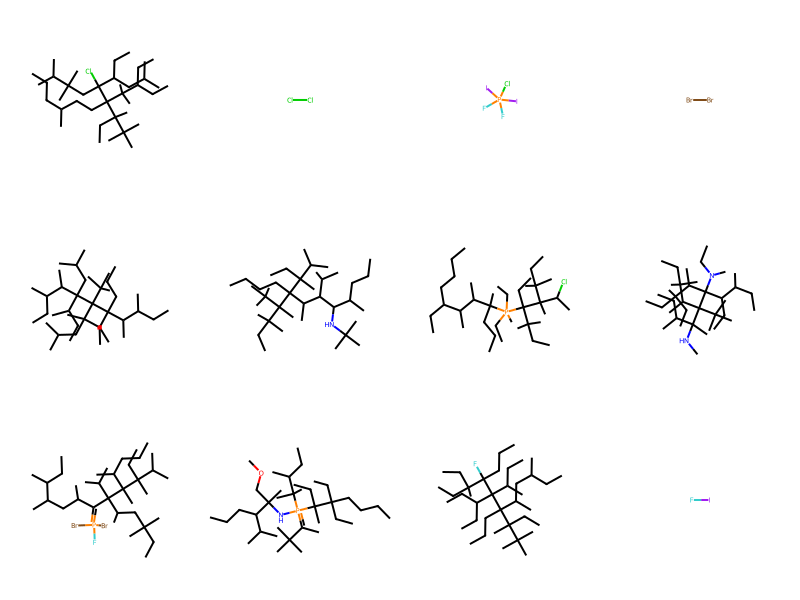

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

sample_smiles = generated_smiles[:12]

mols = [Chem.MolFromSmiles(smi) for smi in sample_smiles if smi]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(200, 200)
)

img

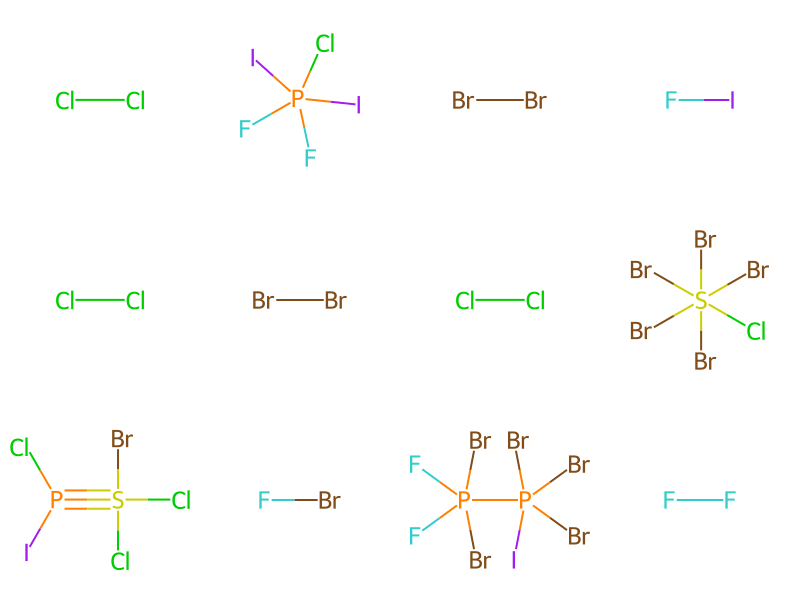

In [ ]:
filtered = []

for smi in generated_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol and len(smi) < 60:
        filtered.append(smi)

sample_smiles = filtered[:12]

mols = [Chem.MolFromSmiles(smi) for smi in sample_smiles if smi]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(200, 200)
)

img

In [ ]:
from rdkit.Chem import Descriptors, QED
rows = []

for smi in generated_smiles:
    mol = Chem.MolFromSmiles(smi)

    rows.append({
        "SMILES": smi,
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "QED": QED.qed(mol)
    })

df = pd.DataFrame(rows)

df.head(10)

,SMILES,MW,LogP,HBD,HBA,QED
0,CCCC(C)CCC(C(C)(C)C(CC)CC)(C(Cl)(CC(C)(C)C(C)C...,583.514,14.2362,0,0,0.132761
1,ClCl,70.906,1.3790,0,0,0.404263
2,FP(F)(Cl)(I)I,358.231,4.1625,0,0,0.450623
3,BrBr,159.808,1.6912,0,0,0.505078
4,CCCC(CC)(C(C)C(C)CC)C(C(C)(C)C)(C(C)(CC)CC(C)C...,563.096,14.1208,0,0,0.146761
5,CCCCC(C(C)C(C(C)C)C(NC(C)(C)C)C(C)CCC)(C(C)(CC...,564.084,12.8251,1,1,0.185446
6,CCCCC(CC)C(C)C(C)C(C)(CCC)P(C)(CC)(CC)C(CC)(C(...,603.485,13.9115,0,0,0.095953
7,CCC(C)C(CC)C(C(C)C(C)(CC)CC)(N(C)CC)C(C(C)C(C)...,565.072,11.3406,1,2,0.177992
8,CCCC(C)C(C)(C(C)(CC)C(C)C)C(C(C(C)CC(C)C(C)CC)...,714.752,15.0087,0,0,0.124049
9,CCCCC(CC)(CC)C(C)(CC)P(NC(C)(COC)C(CCC)C(C)C)(...,584.011,12.2144,1,2,0.152687


In [ ]:
good = []

for smi in generated_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        qed = QED.qed(mol)

        if mw < 500 and logp < 5 and qed > 0.4:
            good.append(smi)

print("Good molecules:", len(good))

Good molecules: 17


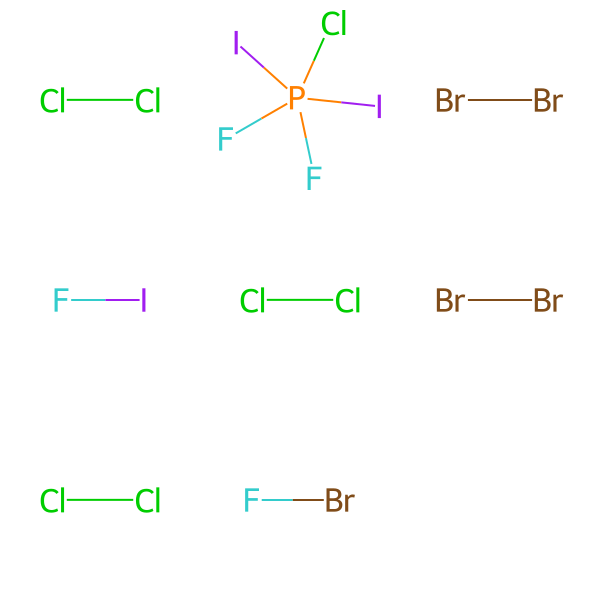

In [ ]:
Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in good[:8]])